# Introduction to Qiskit

Qiskit was launched in 2017 as an open-source Software Development Kit (SDK). Since then, it has evolved into a complete software stack that provides an integrated solution for creating, optimizing, orchestrating, and executing quantum workloads.

Today, the Qiskit SDK represents only one component of this expanded stack, but it remains fundamental. Its architecture, capabilities, and strong focus on the circuit model of quantum computation have significantly shaped the development of the broader Qiskit ecosystem.

Qiskit provides tools to map computational problems into quantum circuits and prepare them for execution. It also offers services for running, optimizing, and orchestrating quantum workloads.

Below is a diagram illustrating the four key stages required to execute a quantum circuit on real hardware: mapping, optimization, execution, and post-processing.

Note: You can explore the fundamentals of Qiskit on the [IBM Quantum Platform](https://quantum.cloud.ibm.com/docs/en/guides).

## Implementing a Quantum Circuit

The first part of this notebook focuses on implementing basic quantum circuits to become familiar with Qiskit’s core features.

We begin by initializing a quantum circuit and applying a single gate:

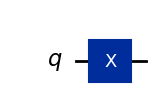

In [1]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# Apply a NOT gate (X gate) to the qubit,
# transforming it from |0> (the initial state) to |1>
qc.x(0)

# Draw the circuit using Matplotlib ("mpl").
# This must be the last line in the cell for the diagram to appear as output.
qc.draw("mpl")

<div class="alert alert-block alert-info">


When representing the state of a multi-qubit system, the tensor order used in Qiskit is different than that used in most physics textbooks. Suppose there are $n$ qubits, and qubit $j$ is labeled as $Q_{j}$. Qiskit uses an ordering in which the $n^{\mathrm{th}}$ qubit is on the <em><strong>left</strong></em> side of the tensor product, so that the basis vectors are labeled as  $Q_{n-1}\otimes \cdots  \otimes  Q_1\otimes Q_0$.

For example, if qubit $Q_{0}$ is in state 0, qubit $Q_{1}$ is in state 0, and qubit $Q_{2}$ is in state 1, Qiskit would represent this state as $|100\rangle$, whereas many physics textbooks would represent it as $|001\rangle$.

This difference in labeling affects the way multi-qubit operations are represented as matrices. For example, Qiskit represents a controlled-X ($C_{X}$) operation with qubit $Q_{0}$ being the control and qubit $Q_{1}$ being the target as

$$C_X = \begin{pmatrix} 1 & 0 & 0 & 0 \\  0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\\end{pmatrix}.$$


**TL;DR** In Qiskit, the ordering convention for qubits in the final results (measurements, statevectors, etc.) follows little-endian ordering, meaning qubits are displayed in reverse order with respect to their circuit indexing.

</div>

### Exercise 0

Construct a quantum circuit that prepares the following state:
$|001\rangle$

In [2]:
qc = QuantumCircuit(3)

# WRITE HERE YOUR CODE
qc.x(0)

# We can verify that the state matches the desired one
# using Qiskit's Statevector class.

from qiskit.quantum_info import Statevector

state = Statevector(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

## Generating an Entangled State (Bell State)

We now aim to implement one of the most fundamental states in quantum computing: a Bell state. One example is

$$|\psi\rangle = \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle \, .$$

This is an entangled state. The two qubits cannot be described independently; their states are intrinsically correlated.

If you measure one of the two qubits, you immediately determine the state of the other. For instance, if measuring the first qubit yields 
0, the second qubit will also collapse to the state $|0\rangle$.
Likewise, obtaining 1 for the first qubit guarantees that the second qubit collapses to $|1\rangle$.

To prepare a Bell state, a simple two-qubit circuit is sufficient, as shown in the next cell

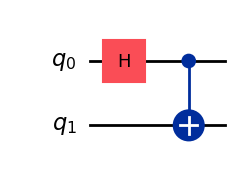

In [3]:
qc_bell_1 = QuantumCircuit(2)
qc_bell_1.h(0)
qc_bell_1.cx(0,1)
qc_bell_1.draw('mpl')

Let's explain the operations in the circuit:
1. In Qiskit, the default intitial state for every qubit is $|0\rangle$ , hence $|\psi\rangle = |00\rangle$
2. By applying the Hadamard gate to the first qubit, we obtain $$
\mathrm{H}|0\rangle=\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1\\
1 & -1\\
\end{bmatrix}
\begin{bmatrix}
1\\
0\\
\end{bmatrix}
=\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
1\\
\end{bmatrix}
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
0\\
\end{bmatrix}+
\frac{1}{\sqrt{2}}
\begin{bmatrix}
0\\
1\\
\end{bmatrix}
=\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle )
$$
Therefore, after the Hadamard gate $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle )|0\rangle = \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|10\rangle$

3. By applying the CNOT gate, the second qubit is flipped only when the first qubit is in the state $|1\rangle$: $|1\rangle$:
$$ \mathrm{CNOT} |\psi\rangle =  \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle $$

We have successfully prepared a Bell state!

In [4]:
state = Statevector(qc_bell_1)
state.draw(output='latex')

<IPython.core.display.Latex object>

### Exercise 1
Write the quantum circuit that implements the Bell state $\frac{1}{\sqrt{2}}|00\rangle - \frac{1}{\sqrt{2}}|11\rangle$

Remember that $\mathrm{H}|1\rangle=\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle )$

In [5]:
qc_bell_2 = QuantumCircuit(2)

# WRITE YOUR CODE HERE
qc_bell_2.x(1)
qc_bell_2.h(1)
qc_bell_2.cx(1,0)

qc_bell_2.draw('mpl')
state = Statevector(qc_bell_2)
state.draw(output='latex')

<IPython.core.display.Latex object>

## Measurements in quantum circuits

Starting from the previous circuit, we can verify that repeated measurements yield either $00$ or $11$. To do this, we measure the observable $\mathrm{Z}$ on both qubits.

The observable $\mathrm{Z}$ corresponds to the matrix
$\begin{bmatrix}
1 & 0\\
0 & -1\\
\end{bmatrix}$,
which can also be written in Dirac notation as
$\mathrm{Z}=+1\times|0\rangle\langle0|-1\times|1\rangle\langle1|$.

This second definition makes the measurement outcomes explicit:
if the qubit is in the state $|0\rangle$, the measurement result is $+1$;
if it is in the state $|1\rangle$, the measurement result is $-1$.

But what happens if the state is in a superposition of $|0\rangle$ and $|1\rangle$?

To clarify this, consider the following single-qubit state:
$|\phi\rangle = \sqrt{\frac{1}{3}}|0\rangle + \sqrt{\frac{2}{3}}|1\rangle$.

In this case, the measurement outcome is probabilistic. Specifically,

$$
\begin{aligned}
\mathrm{Pr}(+1) & = \langle\phi|0\rangle\langle0|\phi\rangle = \bigg(\sqrt{\frac{1}{3}}\langle0|0\rangle + \sqrt{\frac{2}{3}}\langle1|0\rangle\bigg)\times\bigg(\sqrt{\frac{1}{3}}\langle0|0\rangle + \sqrt{\frac{2}{3}}\langle0|1\rangle\bigg) =\bigg(\sqrt{\frac{1}{3}}\times 1 + \sqrt{\frac{2}{3}}\times0\bigg)\times\bigg(\sqrt{\frac{1}{3}}\times1 + \sqrt{\frac{2}{3}}\times0\bigg)=\frac{1}{3} \\
%
\mathrm{Pr}(-1) & = \langle\phi|1\rangle\langle1|\phi\rangle = \bigg(\sqrt{\frac{1}{3}}\langle0|1\rangle + \sqrt{\frac{2}{3}}\langle1|1\rangle\bigg)\times\bigg(\sqrt{\frac{1}{3}}\langle1|0\rangle + \sqrt{\frac{2}{3}}\langle1|1\rangle\bigg) =\bigg(\sqrt{\frac{1}{3}}\times 0 + \sqrt{\frac{2}{3}}\times1\bigg)\times\bigg(\sqrt{\frac{1}{3}}\times0 + \sqrt{\frac{2}{3}}\times1\bigg)=\frac{2}{3}
\end{aligned}
$$
where $\mathrm{Pr}(+1)$ is the probability of measuring $+1$ and $\mathrm{Pr}(-1)$ is the probability of measuring $-1$.

After the measurement, the state is no longer in a superposition: it collapses to $|0\rangle$ if the outcome is $+1$, and to $|1\rangle$ otherwise.

Note: In quantum computing, one typically does not refer to measurement outcomes as $+1$ and $-1$, but rather as $0$ and $1$, to remain consistent with the computational basis states $|0\rangle$ and $|1\rangle$.

Therefore, in the Bell state case, since $\left(\frac{1}{\sqrt{2}}\right)^2 = 0.5$, we will measure $00$ in 50% of the runs and $11$ in the remaining 50%.

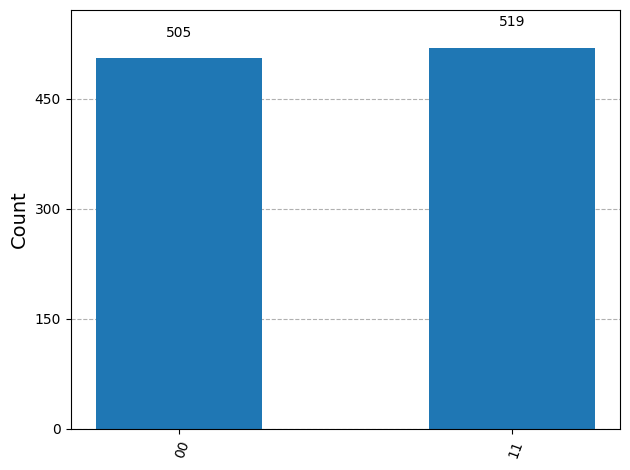

In [6]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

qc_to_sample = qc_bell_1.copy()  # copy the previous circuit
qc_to_sample.measure_all()  # add measurements at the end of the circuit

# StatevectorSampler allows us to simulate the measurement process
sampler = StatevectorSampler()

# Obtain the measurement results
pub = (qc_to_sample)
job = sampler.run([pub], shots=1024)
result = job.result()[0]
data_pub = result.data
bitstrings = data_pub.meas.get_counts()

plot_histogram(bitstrings)

### Exercise 2

Implement the Bell state
$$|\psi\rangle = \frac{1}{\sqrt{2}}|01\rangle + \frac{1}{\sqrt{2}}|10\rangle$$
and perform the measurement as in the previous example.

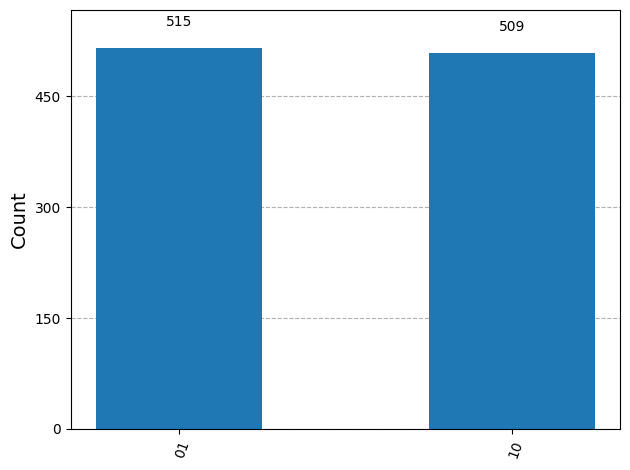

In [7]:
qc_bell_3 = QuantumCircuit(2)

# WRITE YOUR CODE HERE
# Prepare the Bell state (|01> + |10>) / sqrt(2)
# Step 1: Create superposition on the first qubit
qc_bell_3.h(0)
# Step 2: Entangle the qubits
qc_bell_3.cx(0, 1)
# Step 3: Flip the second qubit to obtain (|01> + |10>) / sqrt(2)
qc_bell_3.x(1)
# Add measurements
qc_bell_3.measure_all()

pub = (qc_bell_3)
job = sampler.run([pub], shots=1024)
result = job.result()[0]
data_pub = result.data
bitstrings = data_pub.meas.get_counts()


plot_histogram(bitstrings)

## Expectation Values

In some quantum algorithms, we are interested in a quantity called the expectation value of an observable $O$, which is the average of the measurement outcomes of $O$.

For example, consider the Bell state. Suppose we are interested in the observable $\mathrm{Z}$ acting on the first qubit. This can be written as $\mathrm{Z} \otimes \mathrm{I}$, since applying the identity operator $\mathrm{I}$ to the second qubit is equivalent to doing nothing.

The expectation value is given by
$$
\begin{split}
\langle \mathrm{Z}\otimes\mathrm{I} \rangle 
  &= \langle \psi | \mathrm{Z}\otimes\mathrm{I} | \psi \rangle \\
  &= \frac{1}{\sqrt{2}}(\langle 00| + \langle 11 |) (\mathrm{Z}\otimes\mathrm{I}) \frac{1}{\sqrt{2}} (|00\rangle  + |11\rangle ) \\
  &= \frac{1}{2}(\langle 00| + \langle 11 |) (|00\rangle  - |11\rangle ) \\
  &= \frac{1}{2} (\langle 00|00\rangle - \langle 00|11\rangle + \langle 11|00\rangle - \langle 11|11\rangle) \\
  &= \frac{1}{2}(1 + 0 + 0 -1) = 0 \, .
\end{split}
$$

This result can also be understood intuitively. Looking at the coefficients of the Bell state $\left(\frac{1}{\sqrt{2}}\right)$, we see that half of the time the measurement outcome will be $+1$ and half of the time $-1$. Therefore, their average is zero.

Note: In Qiskit, qubits are ordered according to the little-endian convention: qubit 0 is the least significant bit. As a result, the tensor-product ordering in operators is reversed with respect to the visual order of qubits in the circuit diagram.

Therefore, if you want to compute the expectation value of $\mathrm{Z}$ acting on the first (top) qubit in a two-qubit circuit, you must write the operator as $\mathrm{I} \otimes \mathrm{Z}$ in Qiskit.

In other words, the rightmost operator in the tensor product acts on qubit 0.

In [8]:
from qiskit.quantum_info import Pauli
from qiskit.primitives import StatevectorEstimator

observables = Pauli("IZ")

estimator = StatevectorEstimator()

pub = (qc_bell_1, observables)
job = estimator.run([pub])

result = job.result()[0]

print(result.data.evs)

0.0


### Exercise 3

Consider the Bell state $|\psi\rangle = \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle$
What is the expectation value of
$\langle \mathrm{Z}\otimes\mathrm{Z} \rangle$?

First determine the theoretical result (either intuitively and/or through an explicit calculation), and then verify it using Qiskit.

In [9]:
observables = Pauli('ZZ')# WRITE YOUR CODE HERE

pub = (qc_bell_1, observables)
job = estimator.run([pub])

result = job.result()[0]

print(result.data.evs)

0.9999999999999998


## GHZ State

Another widely used quantum state is the Greenberger–Horne–Zeilinger (GHZ) state.

In the three-qubit case, it can be written as
$$|\mathrm{GHZ}\rangle = \frac{1}{\sqrt{2}}|000\rangle + \frac{1}{\sqrt{2}}|111\rangle$$.

This state represents a maximally entangled tripartite system. All three qubits are perfectly correlated: measuring one immediately determines the state of the others.

### Exercise 4

Construct the quantum circuit required to prepare the state $|\mathrm{GHZ}\rangle$.

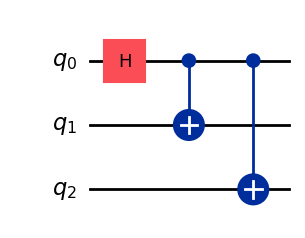

In [10]:
qc_ghz = QuantumCircuit(3)

# WRITE YOUR CODE HERE
qc_ghz.h(0)
qc_ghz.cx(0,1)
qc_ghz.cx(0,2)

qc_ghz.draw('mpl')

In [11]:
state = Statevector(qc_ghz)
state.draw(output='latex')

<IPython.core.display.Latex object>